In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

import prism

from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import GenericStocks, MaterialIntensities

from imagematerials.preprocessing import get_preprocessing_data



In [2]:
scenario_list = {"SSP2_baseline":("SSP2_baseline", None)}

In [3]:
import pandas as pd
import pym
import prism

from imagematerials.read_mym import read_mym_df
from pathlib import Path
from imagematerials.read_mym import mymarray_to_xarray

scenario = "SSP2_baseline"
image_directory = Path(f"../data/raw/image/{scenario}/")

# appliance_diffusion: pd.DataFrame = read_mym_df(image_directory.joinpath("Socioeconomic",
#                                                                                 "sva_pc.scn"))

appliances_diffusion = mymarray_to_xarray(pym.read_mym('EnergyServices/Appl_diffusion.out',image_directory),
                                       dim_1="NRT", dim_2="TURQ", dim_3="Appliances")

appliances_end_use_energy = mymarray_to_xarray(pym.read_mym('EnergyServices/ApplEnUse.out',image_directory),
                                       dim_1="NRT", dim_2="TURQ", dim_3="AppliancesOther")

households = mymarray_to_xarray(pym.read_mym('Socioeconomic/Households.out',image_directory),
                                       dim_1="NRT", dim_2="TURQ")

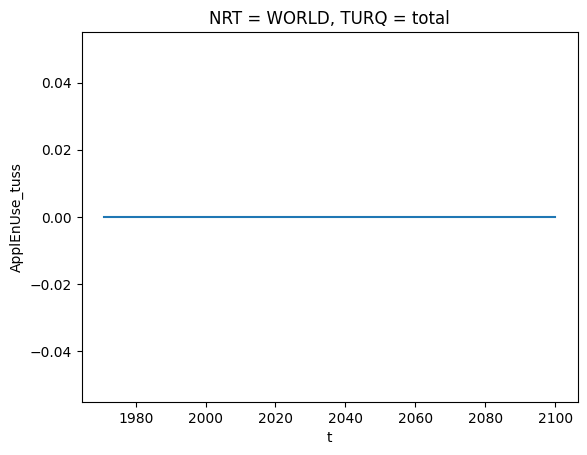

In [ ]:
appliances_end_use_energy.sel(AppliancesOther=["other"]).sum(dim="AppliancesOther").sel(TURQ = "total").sel(NRT = "WORLD").plot()
# delete other appliances, as they are empty, then rename 

In [5]:
# split up xarray in cooling and other applainces, as unit is different
cooling_appliances = appliances_diffusion.sel(Appliances=["Air Conditioner", "Refrigerator"])

In [6]:
scenario_base_path = Path("../data/raw") / 'circular_economy_scenarios'

time_start = 1971
complete_timeline = prism.Timeline(1971, 2060, 1)
simulation_timeline = prism.Timeline(1971, 2060, 1)

all_output = {}

for scen_id, (climate_scen, circular_scen) in scenario_list.items():
    climate_policy_scenario_dir = Path("..", "data", "raw", "image", climate_scen)
    circular_economy_scenario_dirs = None

    bld_sector = get_preprocessing_data("buildings", Path("..", "data", "raw"), 
                                        climate_policy_scenario_dir, 
                                        circular_economy_scenario_dirs) 


    factory = ModelFactory(
    [bld_sector], complete_timeline
    ).add(Stocks, ["buildings"]
    ).add(MaterialIntensities, "buildings",
)
    model = factory.finish()

    import warnings
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model.simulate(simulation_timeline)

    print(f"Finished {scen_id}")

FUNCTION CALLED
ce keys: []
ce_scen = None


c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\index

NameError: name 'Stocks' is not defined